# 01_回归算法-广义线性模型

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/AmesHousing.csv`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 本地没有原文的 insurance.csv；Gamma GLM 改为 AmesHousing 的正值 SalePrice，使用居住面积、质量、房屋类型与中央空调作为特征。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿和大家聊聊回归算法方面的广义线性模型。

首先，带大家回顾一下回归算法：

回归算法是一种**预测数值的工具**。比如：

- 预测房价
- 预测明天温度
- 预测一个产品卖多少钱

只要你的问题是“想预测一个具体的数值”，那多半就会用到回归算法。

最基础的回归算法是**线性回归**。

核心思想是：

**用一个直线公式**（比如 `y = a * x + b`）来描述输入 `x` 和输出 `y` 的关系。

比如：你想根据「房子的面积」来预测「房子的价格」，假设你发现：面积越大，价格越高，而且是差不多成比例的，那就可以用直线来表达它们的关系。

### 广义线性模型

那什么是**广义**线性模型（Generalized Linear Model，GLM）？

可以这么理解：

> 普通线性回归，只能解决“输入和输出之间关系是线性的，输出是连续数值”的问题。

> 但现实中的问题更复杂，比如：

- 输出可能是一个概率（比如预测某人得病的概率）
- 输出可能是一个整数（比如预测某地一天卖出多少个汉堡）

这时候，**普通的线性回归就搞不定了**。  
所以我们就扩展它，变得“更通用”一些 —— 这就是广义线性模型。

### GLM 如何“广义”？

GLM 相比普通线性回归，多了两点：

1. **不一定要求输出是连续数值**（可以是整数、概率等）
2. **使用一个“链接函数”（Link Function）来连接输入和输出**

简单说就是：我们不直接让输入乘权重后输出结果，而是先经过一个“变换函数”，让它能适应不同类型的输出。

### 两个常见的 GLM 应用例子

#### 1. 逻辑回归（Logistic Regression）

- 用来预测：结果是**0 或 1**的分类（比如某人是否会买东西）
- 输出：一个介于 0 到 1 之间的概率
- 使用的“链接函数”：logit 函数（S型曲线）

虽然叫“回归”，但其实是一种分类算法，是 GLM 的特例。

#### 2. 泊松回归（Poisson Regression）

- 用来预测：**整数计数**（比如一分钟内电话呼入次数、商店一天卖出多少瓶水）
- 输出：非负整数
- 使用的链接函数：对数函数（log）

总的来说，广义线性模型是对普通线性回归的扩展，能处理更复杂的预测问题，包括概率、计数、分类等情况。

它的核心思想是：**通过一个“链接函数”，把输入变量和不同类型的输出联系起来。**

## 原理详解

### 数学原理

广义线性模型是一种统计建模方法，**用来处理响应变量（因变量）分布不是正态分布的情况**。

GLM 的数学模型包括以下三部分：

#### 1. 随机成分（Random Component）

指响应变量 $Y$ 的概率分布。

在 GLM 中，要求 $Y$ 来自**指数分布族（Exponential Family）**。

#### 2. 系统成分（Systematic Component）

解释变量（自变量）通过一个**线性预测函数（Linear Predictor）**组合起来：


$$
\eta = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p = \mathbf{x}^T \boldsymbol{\beta}
$$


其中：

$\eta$：线性预测值（不是最终输出）

$\mathbf{x}$：输入向量（特征）

$\boldsymbol{\beta}$：待学习的权重向量

#### 3. 链接函数（Link Function）

连接“线性预测值” $\eta$ 和“响应变量的期望值” $\mu = \mathbb{E}[Y]$：


$$
g(\mu) = \eta\quad \Longleftrightarrow \quad\mu = g^{-1}(\eta)
$$


这个函数 $g(\cdot)$ 就是“链接函数”。

GLM 的形式就是：


$$
Y \sim \text{Exponential Family} \quad \text{with} \quad g(\mathbb{E}[Y]) = \mathbf{x}^T \boldsymbol{\beta}
$$


### 指数分布族的定义（Exponential Family）

GLM 要求响应变量 $Y$ 的分布属于**指数族分布**，其一般形式如下：


$$
f_Y(y;\theta,\phi) = \exp\left( \frac{y\theta - b(\theta)}{\phi} + c(y,\phi) \right)
$$


其中：

- $\theta$：自然参数（natural parameter）
- $\phi$：尺度参数（如标准差的平方）
- $b(\theta)$：规范函数（保证正则性）
- $c(y, \phi)$：与 $y$ 和 $\phi$ 相关的函数，但和 $\theta$ 无关

常见的属于这个族的分布：

| 分布类型 | 链接函数 $g(\mu)$ | 说明 |
|-|-|-|
| 正态分布 | 恒等函数 $g(\mu) = \mu$ | 普通线性回归 |
| 伯努利分布 | logit 函数 | 逻辑回归 |
| 泊松分布 | 对数函数 $\log(\mu)$ | 泊松回归（预测整数计数） |
| 伽马分布 | 倒数函数 $1/\mu$ | 用于预测正值、右偏数据 |

### GLM 的极大似然估计推导（MLE）

GLM 是通过**极大似然估计**来求解参数 $\boldsymbol{\beta}$。

#### 1. 构造似然函数

给定 $n$ 个独立样本 $(x_i, y_i)$，假设 $y_i \sim \text{Exponential Family}$，那么联合似然为：


$$
L(\boldsymbol{\beta}) = \prod_{i=1}^{n} f(y_i; \theta_i, \phi)
$$


取对数，得到对数似然函数（便于优化）：


$$
\ell(\boldsymbol{\beta}) = \sum_{i=1}^{n} \left[ \frac{y_i \theta_i - b(\theta_i)}{\phi} + c(y_i, \phi) \right]
$$


注意：$\theta_i$ 通过链接函数间接由 $\boldsymbol{\beta}$ 决定，即：


$$
\mu_i = \mathbb{E}[Y_i]
$$


$$
\eta_i = \mathbf{x}_i^T \boldsymbol{\beta}
$$


$g(\mu_i) = \eta_i$，或 $\mu_i = g^{-1}(\eta_i)$

$\theta_i$ 是 $\mu_i$ 的函数

#### 2. 求导：得一阶导数（梯度）

我们对对数似然函数 $\ell(\boldsymbol{\beta})$ 关于 $\boldsymbol{\beta}$ 求导，得到：


$$
\frac{\partial \ell}{\partial \boldsymbol{\beta}} = \sum_{i=1}^{n} \left( \frac{\partial \ell}{\partial \theta_i} \cdot \frac{d\theta_i}{d\mu_i} \cdot \frac{d\mu_i}{d\eta_i} \cdot \frac{d\eta_i}{d\boldsymbol{\beta}} \right)
$$


这个链式法则说明了每一步的变量依赖关系。

在实际求解中，一般使用**迭代加权最小二乘法（Iteratively Reweighted Least Squares，IRLS）**来逼近解。

### GLM 的算法流程（IRLS 简述）

广义线性模型通常用 IRLS 来解，即通过一系列**加权的线性回归**迭代求出最优 $\boldsymbol{\beta}$。

步骤：

#### 步骤 1：初始化

设定初始权重 $\boldsymbol{\beta}^{(0)}$，一般设为 0 向量。

#### 步骤 2：计算中间变量

对于每个样本点：

- 计算 $\eta_i = \mathbf{x}_i^T \boldsymbol{\beta}$
- 计算 $\mu_i = g^{-1}(\eta_i)$
- 计算一阶导数（工作变量）：


$$
z_i = \eta_i + \frac{y_i - \mu_i}{\frac{d\mu_i}{d\eta_i}}
$$


- 计算加权矩阵 $W_i = \left( \frac{d\mu_i}{d\eta_i} \right)^2 / \text{Var}(Y_i)$

#### 步骤 3：拟合加权最小二乘

用如下的加权最小二乘方法更新 $\boldsymbol{\beta}$：


$$
\boldsymbol{\beta}^{(t+1)} = (\mathbf{X}^T W \mathbf{X})^{-1} \mathbf{X}^T W \mathbf{z}
$$


其中：

$W$：对角矩阵，主对角线为 $W_i$

$\mathbf{z}$：工作变量向量

$\mathbf{X}$：设计矩阵（自变量）

#### 步骤 4：迭代收敛

重复步骤 2\~3，直到 $\boldsymbol{\beta}$ 收敛（如前后变化非常小）为止。

### 总结几点

#### GLM 模型结构：


$$
g(\mathbb{E}[Y]) = \mathbf{x}^T \boldsymbol{\beta}
$$


#### 必须满足：

- 响应变量 $Y$ 属于指数分布族
- 存在线性预测子 $\eta = \mathbf{x}^T \boldsymbol{\beta}$
- 存在链接函数 $g(\cdot)$ 将 $\eta$ 与 $\mathbb{E}[Y]$ 连接

#### 求解方式：

通过极大似然估计，常用 IRLS 算法近似求解

## 完整案例

本例使用本地 AmesHousing.csv 预测房屋成交价 SalePrice。输入为居住面积 GrLivArea、质量评分 OverallQual、房屋类型 HouseStyle 和中央空调 CentralAir。目标为正值，因此用 Gamma 分布与对数链接作为演示模型；是否适合真实数据仍须检查残差和验证误差。

依次读取数据、独热编码、划分训练集与测试集、在训练集上标准化、拟合 GLM。随后查看系数摘要、测试集误差与数据分布。分组图显示观测差异，不支持因果结论。

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 设置中文字体与图像风格
plt.rcParams['font.sans-serif'] = CJK_FONTS
sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = CJK_FONTS
sns.set_palette("Set1")

# 读取数据
df = pd.read_csv(DATA_DIR / 'AmesHousing.csv')[['Gr Liv Area', 'Overall Qual', 'House Style', 'Central Air', 'SalePrice']].rename(columns={'Gr Liv Area': 'GrLivArea', 'Overall Qual': 'OverallQual', 'House Style': 'HouseStyle', 'Central Air': 'CentralAir'})

In [3]:
print(df.head())
print(df.info())

# 将类别变量进行独热编码
df_encoded = pd.get_dummies(df, drop_first=True)

# 特征与目标分开
X = df_encoded.drop("SalePrice", axis=1)
y = df_encoded["SalePrice"]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

   GrLivArea  OverallQual HouseStyle CentralAir  SalePrice
0       1656            6     1Story          Y     215000
1        896            5     1Story          Y     105000
2       1329            6     1Story          Y     172000
3       2110            7     1Story          Y     244000
4       1629            5     2Story          Y     189900
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   GrLivArea    2930 non-null   int64 
 1   OverallQual  2930 non-null   int64 
 2   HouseStyle   2930 non-null   object
 3   CentralAir   2930 non-null   object
 4   SalePrice    2930 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 114.6+ KB
None


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
X_train_const = sm.add_constant(X_train_scaled)

glm_gamma = sm.GLM(y_train, X_train_const, family=sm.families.Gamma(sm.families.links.Log()))
result = glm_gamma.fit()

print(result.summary())
# 使用独立测试集检查泛化误差；正值预测由对数链接保证。
from sklearn.metrics import mean_absolute_error, mean_squared_error
X_test_const = sm.add_constant(X_test_scaled, has_constant='add')
y_pred = result.predict(X_test_const)
print('Test MAE:', mean_absolute_error(y_test, y_pred))
print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
assert np.isfinite(y_pred).all() and (y_pred > 0).all()

                 Generalized Linear Model Regression Results                  
Dep. Variable:              SalePrice   No. Observations:                 2344
Model:                            GLM   Df Residuals:                     2333
Model Family:                   Gamma   Df Model:                           10
Link Function:                    Log   Scale:                        0.027033
Method:                          IRLS   Log-Likelihood:                -27387.
Date:                Sat, 12 Sep 2026   Deviance:                       70.492
Time:                        14:40:20   Pearson chi2:                     63.1
No. Iterations:                    13   Pseudo R-squ. (CS):             0.9924
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.0268      0.003   3541.501      0.0

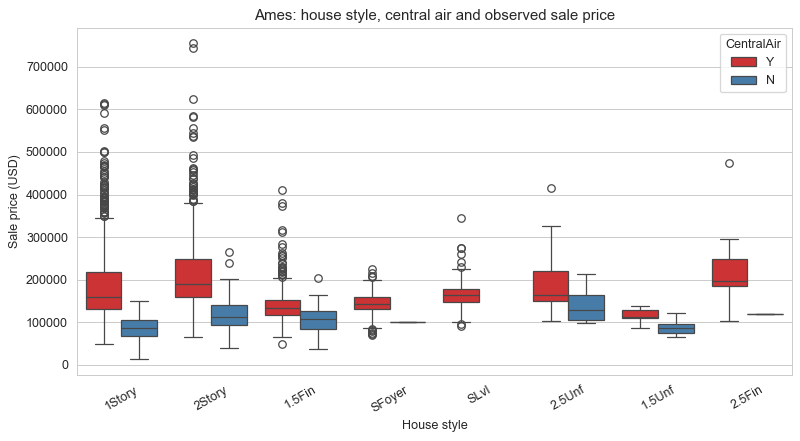

In [6]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='HouseStyle', y='SalePrice', hue='CentralAir')
plt.title('Ames: house style, central air and observed sale price')
plt.xlabel('House style'); plt.ylabel('Sale price (USD)')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

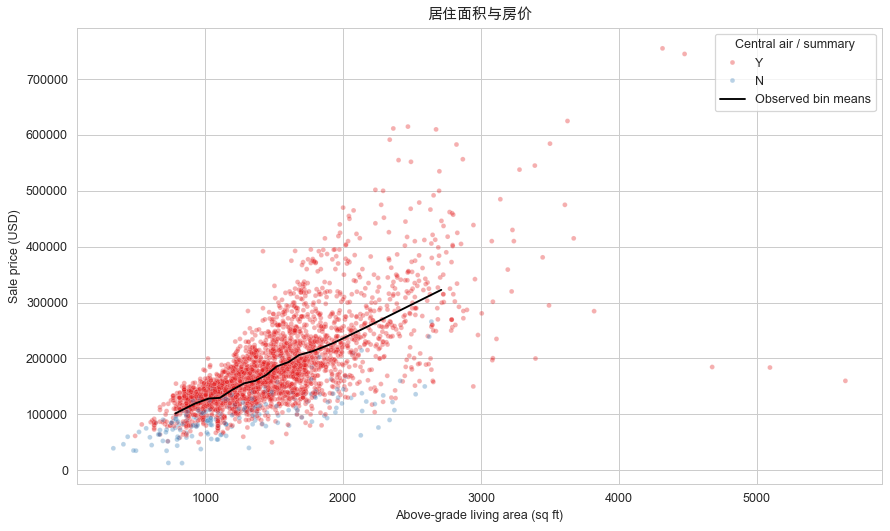

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', hue='CentralAir', alpha=0.35, s=15)
# 描述性分箱均值，不将逐点连线误称为拟合模型。
bins = pd.qcut(df['GrLivArea'], q=15, duplicates='drop')
observed_means = df.groupby(bins, observed=True)[['GrLivArea', 'SalePrice']].mean()
plt.plot(observed_means['GrLivArea'], observed_means['SalePrice'], color='black', label='Observed bin means')
plt.title('居住面积与房价')
plt.xlabel('Above-grade living area (sq ft)'); plt.ylabel('Sale price (USD)')
plt.legend(title='Central air / summary'); plt.tight_layout(); plt.show()

## 模型分析

### 优缺点

**优点：**

1. **适应目标变量的分布特性**：GLM 最大的优势是**不要求目标变量服从正态分布**。在本案例中，医疗费用是非负、偏态分布的连续型变量，使用 Gamma 分布非常契合。相比普通线性回归，GLM 明确建模了响应变量的分布形态，更具统计学合理性。
2. **链接函数灵活建模非线性效应**：GLM 通过链接函数（如对数链接）将非线性响应变量转化为线性组合变量的形式，从而保留线性模型的解释性，同时捕捉一定程度的非线性。
3. **模型解释性强**：与黑箱模型（如神经网络、XGBoost）相比，GLM 的参数系数可以直接用于解释每个特征对预测结果的影响方向和强度，这在医疗、金融、政策等领域尤为重要。
4. **对异常值敏感度中等，依赖分布假设进行建模**：虽然 GLM 比线性回归更具鲁棒性，但也不像树模型那样能完全忽略异常值。它在 Gamma 或 Poisson 分布下通过最大似然估计，相对更加稳健。
5. **训练快速、收敛稳定**：GLM 利用迭代重加权最小二乘法（IRLS）求解，在中等规模的数据集上非常高效，尤其在需要频繁迭代模型时更具优势。

**缺点：**

1. **只能建模链接函数下的“线性关系”**：虽然链接函数可转换变量，但 GLM 本质仍为线性模型。对于变量之间复杂的非线性交互作用（例如吸烟 × BMI × 年龄），若不显式加入交互项，GLM 无法学习这种模式。
2. **高度依赖分布假设**：若目标变量并不真正服从设定的指数族分布（例如 Gamma 或 Poisson），则拟合结果不稳定、预测偏差大。分布假设本身是一种强约束。
3. **特征扩展和预处理负担较重**：类别变量需独热编码，连续变量需标准化。相比树模型，GLM 对预处理的要求更严格，不具备自动处理特征的能力。
4. **不自动建模交互项或高阶非线性项**：若想建模复杂关系，必须手动添加多项式、交互项等，这增加了模型设计复杂度。
5. **对极端异常值仍敏感**：虽然比 OLS 强健一些，但 GLM 仍会受少数极端值影响，尤其在数据量小或极度不平衡时。

### GLM 与相似回归算法的对比

| 维度/算法 | 广义线性模型（GLM） | 线性回归（OLS） | XGBoost/GBDT | 随机森林回归 | 神经网络回归（MLP） |
|-|-|-|-|-|-|
| 支持非正态目标变量 | 是 | 否 | 是 | 是 | 是 |
| 分布建模能力 | 明确建模（指数族） | 无建模 | 无分布建模 | 无分布建模 | 无分布建模 |
| 可解释性 | 强 | 强 | 弱 | 弱 | 弱 |
| 对变量关系建模能力 | 线性为主（靠人工扩展） | 线性 | 自动识别复杂关系 | 自动识别复杂关系 | 自动识别复杂关系 |
| 对缺失值容忍 | 弱 | 弱 | 强 | 强 | 弱（需处理） |
| 对类别变量处理能力 | 需独热编码 | 需独热编码 | 可直接处理 | 可直接处理 | 需编码（或嵌入层） |
| 是否支持目标变量为非负实数 | 是（如 Gamma） | 否 | 是 | 是 | 是（通过激活函数） |
| 对异常值鲁棒性 | 一般 | 差 | 好 | 好 | 差 |
| 训练时间 | 快速 | 非常快 | 中等偏慢 | 中等偏慢 | 慢（尤其深层网络） |
| 参数调节与模型选择复杂性 | 简单 | 简单 | 高 | 高 | 高 |
| 适用任务规模 | 中小规模 | 小规模 | 中到大 | 中到大 | 任意，但需高算力 |

### 何时优选 GLM，何时考虑其他算法

#### 使用 GLM 的推荐场景：

1. **目标变量具有明确定义的分布特征**：如索赔金额、医疗费用、交易额度等偏态、非负连续变量，适合用 Gamma 分布建模
2. **解释性优先的业务应用**：在医疗、保险、政策分析、经济建模中，模型的透明性和可解释性比预测精度更重要
3. **数据质量较高、变量间线性结构明显**：自变量间关系接近线性，无大量复杂交互或非线性行为时，GLM 简洁高效
4. **中小型数据集、训练资源有限**：与复杂模型相比，GLM 训练快、开销小，非常适合小数据集建模和快速原型设计

### 建议考虑其他算法的场景：

1. **变量关系复杂、明显非线性**：如图像特征、用户行为数据、交互行为建模，GLM 难以捕捉非线性结构，应考虑 XGBoost 或神经网络
2. **模型精度优先，解释性可放弃**：在 Kaggle 比赛、电商推荐系统等精度导向场景下，GLM 性能受限
3. **高维、稀疏、类别变量多**：特征空间庞大或存在大量类别特征（如文本、地理编码），应选用对高维更友好的模型，如树模型或嵌入式网络
4. **目标变量分布异常复杂**：若目标变量分布非常不规则、存在多峰、长尾等形态，GLM 很难准确建模，应使用核方法、变换模型或自定义损失

### 总结

广义线性模型（GLM）是一个结构清晰、理论扎实的回归工具，尤其适合需要考虑**目标分布特征**和**模型可解释性**的任务。虽然它在处理复杂非线性关系或极端精度追求上不如现代集成学习或深度学习算法，但在很多传统行业中仍然是首选建模方法。